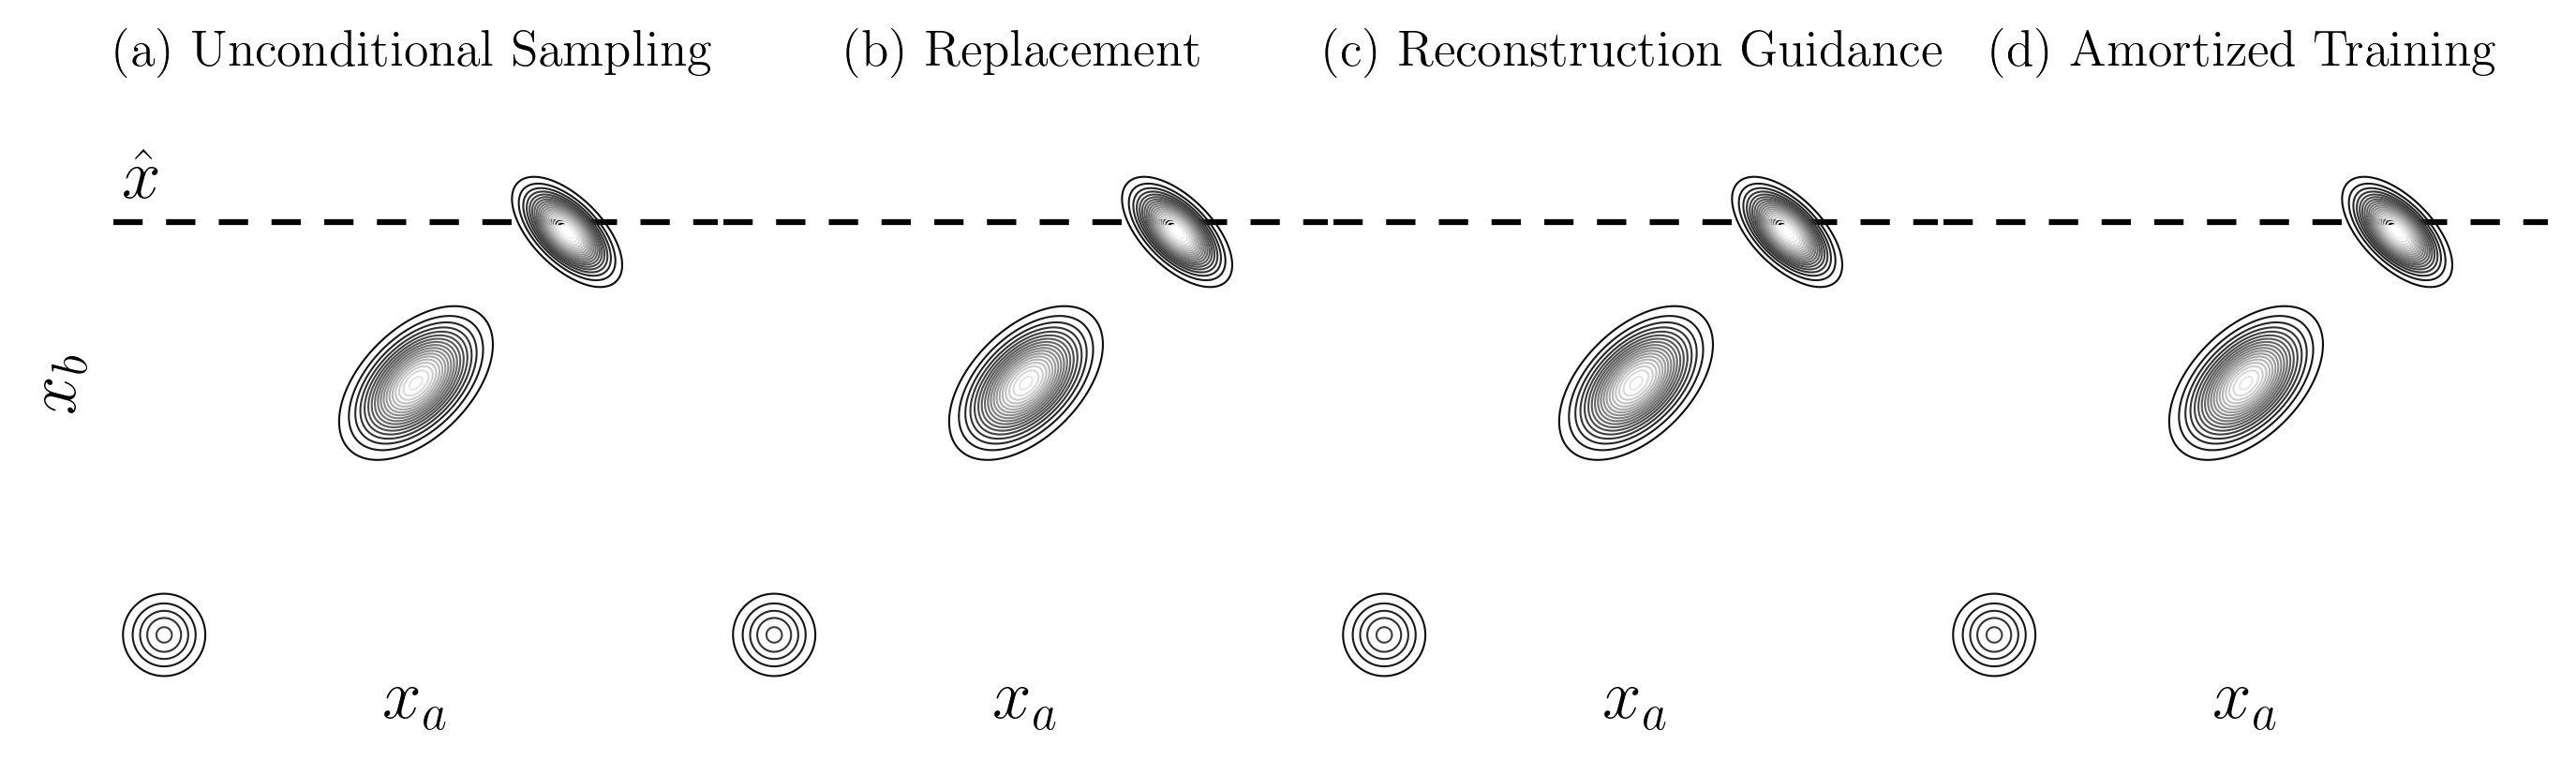

In [14]:
# ---------------------------------------------------------------------------
#  Figure C – four-panel illustration (a-d) of sampling strategies
# ---------------------------------------------------------------------------

from __future__ import annotations

from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import multivariate_normal

# ------------------------------------------------------------------
#  Matplotlib / LaTeX setup  (unchanged)
# ------------------------------------------------------------------
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams.update({"text.usetex": True, "font.family": "serif"})
plt.rc("text.latex", preamble=r"\usepackage{amsfonts}\usepackage{amsmath}")

savepath = Path(
    "/Users/shreyaspadhy/Documents/Obsidian Vault/phd-thesis/Chapter5/Figs/"
)

# ---- master geometry --------------------------------------------------------
BOX = 2.15  # in – size of ONE square axis
PANEL_GAP = 0.02  # in – horizontal gap between neighbouring axes

# convenience: convert gap (in) → fraction of axis‑width required by subplots_adjust
WS_FRACTION = PANEL_GAP / BOX

# -----------------------------------------------------------------------------
#  Utilities
# -----------------------------------------------------------------------------


def clean_axis(ax):
    """Strip all spines and ticks for a minimalist look."""
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(False)
    ax.tick_params(direction="out", length=3, width=0.7)


# -----------------------------------------------------------------------------
#  Distributions
# -----------------------------------------------------------------------------


def f_T(x: np.ndarray) -> np.ndarray:
    means = [np.array([0.0, 0.0]), np.array([1.5, 1.5]), np.array([-2.5, -2.5])]
    covs = [
        np.array([[0.1, 0.05], [0.05, 0.1]]),
        np.array([[0.05, -0.03], [-0.03, 0.05]]),
        np.array([[0.05, 0.0], [0.0, 0.05]]),
    ]
    weights = [0.6, 0.3, 0.1]
    pdf = np.zeros(x.shape[0])
    for w, m, c in zip(weights, means, covs):
        pdf += w * multivariate_normal(m, c).pdf(x)
    return pdf


def f_0(x: np.ndarray) -> np.ndarray:
    return multivariate_normal(np.zeros(2), np.eye(2)).pdf(x)


def f_t(x: np.ndarray, beta: float) -> np.ndarray:
    return np.power(f_0(x), 1.0 - beta) * np.power(f_T(x), beta)


# -----------------------------------------------------------------------------
#  Common grid for contour plots
# -----------------------------------------------------------------------------

gridx, gridy = np.mgrid[-3:3:0.01, -3:3:0.01]
GRID = np.dstack((gridx, gridy))
PDF_T = f_T(GRID.reshape(-1, 2)).reshape(GRID.shape[:2])

# colour
sns_blue = sns.color_palette("tab10")[0]

# ---------------------------------------------------------------------------
#  Figure A – importance‑sampling proposals (2 panels)
# ---------------------------------------------------------------------------

N = 100
q_1 = multivariate_normal(np.array([-2.0, -2.0]), 0.1 * np.eye(2))
q_2 = multivariate_normal(np.array([0.0, 0.0]), np.eye(2))

samples = [q_1.rvs(N), q_2.rvs(N)]
q_pdfs = [
    q_1.pdf(GRID.reshape(-1, 2)).reshape(GRID.shape[:2]),
    q_2.pdf(GRID.reshape(-1, 2)).reshape(GRID.shape[:2]),
]

# figA_w = 2 * BOX + PANEL_GAP  # two panels → one gap
# figA_h = BOX + 0.05  # tiny head‑room for title / legend


panel_titles = [
    r"(a) Unconditional Sampling",
    r"(b) Replacement",
    r"(c) Reconstruction Guidance",
    r"(d) Amortized Training",
]

# -----------  “scriptable” coordinates: tweak here if you want  ---------------
#   Each entry is a list of successive 2-D points (x_a, x_b) – they are plotted
#   as red ✕’s and connected with black (or grey) arrows.
PANEL_PATHS = {
    0: [(-0.6, -0.3), (-0.1, -0.8), (0.35, -1.2)],  # (a)
    1: [(-0.2, 0.1), (0.55, -0.2), (0.55, -1.2), (0.55, -2.3)],  # (b)
    2: [(0.50, -0.2), (0.80, -0.7), (0.30, -1.5), (-0.60, -1.5)],  # (c)
    3: [(-1.8, -1.8), (-1.0, -1.0), (-0.1, -0.4), (0.6, 0.2)],  # (d)
}
#   points in panel (c) you want in *grey* (dashed “rejected” moves)
GREY_SEGMENTS_C = {(1, 2), (2, 3)}  # pairs of successive indices

# ---------------------------------------------------------------------------

N_PANELS = 4
fig_w = N_PANELS * BOX + (N_PANELS - 1) * PANEL_GAP
fig_h = BOX + 0.05
figC, axC = plt.subplots(
    1, N_PANELS, figsize=(fig_w, fig_h), dpi=300, sharex=True, sharey=True
)
figC.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=WS_FRACTION, hspace=0)

# pre-compute the brown dashed reference line ( x_b = x̂ )
REF_Y = 1.6

for idx, ax in enumerate(axC):
    # 1 – target contours
    ax.contour(
        gridx,
        gridy,
        PDF_T,
        levels=22,
        cmap="grey",
        linewidths=0.5,
    )

    # 2 – horizontal dashed reference
    ax.axhline(
        REF_Y,
        ls=(0, (5, 4)),
        lw=1.5,
        color="black",
        zorder=0,  # "saddle-brown"
    )
    # Add label for the reference line

    # # 3 – red crosses & arrows ------------------------------------------------
    # pts = np.asarray(PANEL_PATHS[idx])
    # # red ✕’s
    # ax.scatter(pts[:, 0], pts[:, 1], s=32, color="firebrick", marker="x", zorder=4)

    # # arrows: iterate over successive pairs
    # for k in range(len(pts) - 1):
    #     col = "grey" if (idx == 2 and (k, k + 1) in GREY_SEGMENTS_C) else "black"
    #     arr = FancyArrowPatch(
    #         pts[k], pts[k + 1],
    #         arrowstyle="->,head_length=4,head_width=2",
    #         mutation_scale=8,
    #         lw=1.8, color=col, zorder=3,
    #     )
    #     ax.add_patch(arr)

    # 4 – cosmetic bits
    ax.set_title(panel_titles[idx], fontsize=13, pad=4)
    ax.set(xlim=(-3, 3), ylim=(-3, 3))
    ax.set_xticks([]), ax.set_yticks([])
    ax.set_aspect("equal")
    ax.grid(False)
    clean_axis(ax)


axC[0].text(-2.9, REF_Y + 0.1, r"$\hat{x}$", fontsize=18, va="bottom")
# nice axis labels on the outer-left / bottom only
axC[0].set_ylabel(r"$x_b$", fontsize=18, labelpad=6)
for ax in axC:
    ax.set_xlabel(r"$x_a$", fontsize=18, labelpad=-4)

# ---------------------------------------------------------------------------
#  Save (optional)
# ---------------------------------------------------------------------------
(figC_out := savepath / "Vector" / "four_panel_sampling.pdf").parent.mkdir(
    parents=True, exist_ok=True
)
figC.savefig(figC_out, transparent=True, bbox_inches="tight")
figC.savefig(
    savepath / "Raster" / "four_panel_sampling.png",
    dpi=450,
    transparent=True,
    bbox_inches="tight",
)